### Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.over_sampling import BorderlineSMOTE, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from scipy import stats
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

### Load Data

In [4]:
# Load the uploaded label file
df = pd.read_csv("hscssp3_dr17_gc1_class_rs20231229.csv")

# Show structure of labels
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 687859 entries, 0 to 687858
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              687859 non-null  int64  
 1   id_sdss         687859 non-null  int64  
 2   ra              687859 non-null  float64
 3   dec             687859 non-null  float64
 4   skymap_id       687859 non-null  int64  
 5   sample          687859 non-null  str    
 6   z               687859 non-null  float64
 7   z_flag          687859 non-null  str    
 8   prob_sp         687859 non-null  float64
 9   prob_rg         687859 non-null  float64
 10  reduced_chisq   687859 non-null  float64
 11  mstar           687859 non-null  float64
 12  mstar_err68min  687859 non-null  float64
 13  mstar_err68max  687859 non-null  float64
 14  sfr             687859 non-null  float64
 15  sfr_err68min    687859 non-null  float64
 16  sfr_err68max    687859 non-null  float64
dtypes: float64(12), int64

In [5]:
df.describe()

,id,id_sdss,ra,dec,skymap_id,z,prob_sp,prob_rg,reduced_chisq,mstar,mstar_err68min,mstar_err68max,sfr,sfr_err68min,sfr_err68max
count,6.878590e+05,6.878590e+05,687859.000000,687859.000000,6.878590e+05,687859.000000,6.878590e+05,6.878590e+05,687859.000000,6.878590e+05,6.878590e+05,6.878590e+05,687859.000000,687859.000000,687859.000000
mean,4.470470e+16,1.237661e+18,184.465003,4.572226,1.016458e+08,0.189657,5.687565e-01,7.003723e-02,6.794549,3.435778e+10,2.923351e+10,4.026368e+10,2.119827,1.431081,3.153164
std,7.713668e+15,1.056902e+13,92.420463,11.715066,1.753885e+07,0.065101,4.211279e-01,1.846380e-01,63.226635,5.833483e+10,5.400514e+10,6.274300e+10,4.166936,3.138394,5.586419
min,3.641144e+16,1.237646e+18,0.000672,-7.280866,8.279000e+07,0.010100,2.349270e-12,2.044375e-22,0.000000,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,-99.000000,-99.000000
25%,4.119733e+16,1.237652e+18,146.239611,-0.416252,9.367060e+07,0.140848,8.190204e-02,5.775361e-03,1.232500,8.691950e+09,7.448100e+09,1.034300e+10,0.286015,0.142800,0.469960
50%,4.269269e+16,1.237655e+18,184.836993,1.417463,9.707061e+07,0.191752,7.160867e-01,1.178165e-02,2.987500,2.140200e+10,1.805500e+10,2.566800e+10,0.970910,0.688740,1.405300
75%,4.429344e+16,1.237671e+18,219.844458,3.577509,1.007105e+08,0.243768,9.946561e-01,2.582063e-02,6.435000,4.365000e+10,3.658000e+10,5.229550e+10,2.375600,1.642750,3.558850
max,7.464917e+16,1.237680e+18,359.999356,53.246110,1.697308e+08,0.300000,1.000000e+00,9.999042e-01,24160.100000,9.334100e+12,9.080000e+12,9.535100e+12,612.140000,568.530000,664.410000


In [ ]:
# make class from  'prob_sp'
def make_target(p):
    if p > 0.79:
        return "Spiral"
    elif p < 0.5:
        return "Non-Spiral"
    else:
        return "Intermediate"

df["target_class"] = df["prob_sp"].apply(make_target)

print("\nDistribusi target_class:")
print(df["target_class"].value_counts())

# Drop only identity

drop_cols = ["id", "id_sdss", "skymap_id", "ra", "dec"]
df_proportion = df["target_class"]
df_proportion.to_csv("data_gc_proportion.csv", index=False)
df = df.drop(columns=drop_cols)

print("\nKolom setelah drop ID:")
print(df.columns)

# One-hot encoding only for categorical columns

categorical_cols = ["sample", "z_flag"]

df = pd.get_dummies(df, columns=categorical_cols)

# Convert bool → int (0/1)
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print("\nKolom setelah OneHotEncoding:")
print(df.columns)
# Label encoding target

le = LabelEncoder()
df["target_class"] = le.fit_transform(df["target_class"])

print("\nMapping target_class:")
for i, cls in enumerate(le.classes_):
    print(f"{cls} → {i}")

# prob_sp used as a target, so it must be dropped
X = df.drop(columns=["target_class", "prob_sp"])
y = df["target_class"]
# Normalization

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Combine back with target
df_final = X_scaled.copy()
df_final["target_class"] = y.values


Distribusi target_class:
target_class
Spiral          328114
Non-Spiral      302203
Intermediate     57542
Name: count, dtype: int64

Kolom setelah drop ID:
Index(['sample', 'z', 'z_flag', 'prob_sp', 'prob_rg', 'reduced_chisq', 'mstar',
       'mstar_err68min', 'mstar_err68max', 'sfr', 'sfr_err68min',
       'sfr_err68max', 'target_class'],
      dtype='str')

Kolom setelah OneHotEncoding:
Index(['z', 'prob_sp', 'prob_rg', 'reduced_chisq', 'mstar', 'mstar_err68min',
       'mstar_err68max', 'sfr', 'sfr_err68min', 'sfr_err68max', 'target_class',
       'sample_main', 'sample_sub', 'z_flag_phot', 'z_flag_spec'],
      dtype='str')

Mapping target_class:
Intermediate → 0
Non-Spiral → 1
Spiral → 2


In [ ]:
# Preparation data using df_final
# Split features and target from df_final
X = df_final.drop('target_class', axis=1)
y = df_final['target_class']

print("=" * 60)
print("Data before Resampling")
print("=" * 60)
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print("\nClass distribution before Resampling:")
print(y.value_counts().sort_index())
for cls in sorted(y.unique()):
    count = (y == cls).sum()
    print(f"  Class {cls}: {count} samples ({count/len(y)*100:.2f}%)")

# Calculate class weights from original distribution
classes = np.unique(y)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)
class_weight_dict = dict(zip(classes, class_weights))

print("\n" + "=" * 60)
print("Class Weights")
print("=" * 60)
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")

# Resampling with undersampling or oversampling, choose one 

# Undersampling
nearmiss = NearMiss(
   version=1,  
    n_neighbors=3
)
# Oversampling
# smote_tomek = SMOTETomek()

# X_resampled, y_resampled = smote_tomek.fit_resample(X, y)
X_resampled, y_resampled = nearmiss.fit_resample(X, y)

print("\n" + "=" * 60)
print("Data after Resampling")
print("=" * 60)
print(f"Shape X_resampled: {X_resampled.shape}")
print(f"Shape y_resampled: {y_resampled.shape}")
print("\nClass distribution after Resampling:")
unique, counts = np.unique(y_resampled, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} samples ({count/len(y_resampled)*100:.2f}%)")

# Convert to DataFrame for easier LDA later
X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled_series = pd.Series(y_resampled, name='target_class')

# LDA (Dimensionality Reduction)

print("LDA")
lda = LinearDiscriminantAnalysis(
    n_components=2        # 3 classes → max 2
)

X_lda = lda.fit_transform(X_resampled, y_resampled)

print("\nDiscriminant Power:")
for i, ratio in enumerate(lda.explained_variance_ratio_):
    print(f" LD{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")


# Final Data

X_final = pd.DataFrame(X_lda, columns=['LD1','LD2'])
y_final = pd.Series(y_resampled)

print("\nFinal shape for FNN:", X_final.shape)

Data before Resampling
Shape X: (687859, 13)
Shape y: (687859,)

Class distribution before Resampling:
target_class
0     57542
1    302203
2    328114
Name: count, dtype: int64
  Class 0: 57542 samples (8.37%)
  Class 1: 302203 samples (43.93%)
  Class 2: 328114 samples (47.70%)

Class Weights
  Class 0: 3.9847
  Class 1: 0.7587
  Class 2: 0.6988

Data after Resampling
Shape X_resampled: (172626, 13)
Shape y_resampled: (172626,)

Class distribution after Resampling:
  Class 0: 57542 samples (33.33%)
  Class 1: 57542 samples (33.33%)
  Class 2: 57542 samples (33.33%)
LDA

Discriminant Power:
 LD1: 0.9208 (92.08%)
 LD2: 0.0792 (7.92%)

Final shape for FNN: (172626, 2)


In [10]:
df_lda_visual = pd.DataFrame(data=X_final, columns=["LD1", "LD2"])
df_lda_visual['Class'] = y_final
df_lda_visual

centroids = df_lda_visual.groupby('Class')[['LD1', 'LD2']].mean()

# Display centroids
print(centroids)

            LD1       LD2
Class                    
0     -0.819599  0.049701
1      0.263017 -0.232988
2      0.556583  0.183287


In [ ]:
df_lda_visual = pd.DataFrame(data=X_final, columns=["LD1", "LD2"])
df_lda_visual['Class'] = y_final
# Save to CSV
df_lda_visual.to_csv("df_lda_visual_over.csv", index=False)

,LD1,LD2,Class
0,-0.351386,-0.180748,0
1,-0.590366,0.514105,2
2,-0.447691,-0.128630,2
3,0.582098,-0.285508,1
4,0.405988,-0.904721,1
...,...,...,...
872197,-0.044202,-0.511100,1
872198,0.183980,-0.425209,1
872199,-0.642717,0.264653,1
872200,2.372025,0.479992,1


In [11]:
# Reload the saved CSV
df_lda_visual = pd.read_csv("df_lda_visual_over.csv")
X_lda = df_lda_visual[["LD1", "LD2"]]
y_final = df_lda_visual["Class"]

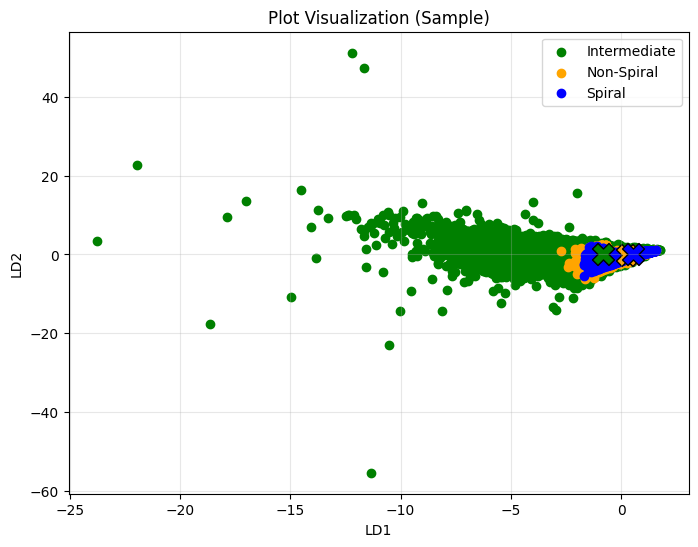

In [ ]:
# Plot sample after LDA
class_names = ['Intermediate', 'Non-Spiral', 'Spiral']
colors = ['green', 'orange', 'blue']

plt.figure(figsize=(8,6))

# Plot data tiap kelas
for i, class_id in enumerate(sorted(np.unique(y_final))):
    mask = y_final == class_id
    plt.scatter(
        X_lda[mask, 0],
        X_lda[mask, 1],
        label=class_names[i],
        color=colors[i]
    )

# Hitung centroid
centroids = df_lda_visual.groupby('Class')[['LD1','LD2']].mean()

# Plot centroid + label
for i, class_id in enumerate(centroids.index):
    
    x = centroids.loc[class_id, 'LD1']
    y = centroids.loc[class_id, 'LD2']

    plt.scatter(
        x, y,
        color=colors[i],
        marker='X',
        s=250,
        edgecolors='black'
    )

plt.xlabel(f"LD1")
plt.ylabel(f"LD2")
plt.title("Plot Visualization (Sample)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
class LDAFuzzyMembershipMuSigma:
    def __init__(self, X):
        self.X = X
        self.n_features = X.shape[1]
        self.params = []
        self._build_membership()

    def _build_membership(self):
        for i in range(self.n_features):
            alpha = 1 # Parameter width of the trapezoidal membership function
            xi = self.X[:, i]

            xmin = np.min(xi)
            xmax = np.max(xi)
            mu = np.mean(xi)
            sigma = np.std(xi)

            feature_params = {
                "low":    [xmin, xmin, mu - alpha*sigma, mu],
                "medium": [mu - alpha*sigma, mu, mu, mu + alpha*sigma],
                "high":   [mu, mu + alpha*sigma, xmax, xmax]
            }

            self.params.append(feature_params)

    def trapezoidal(self, x, a, b, c, d):
        return np.maximum(
            np.minimum(
                np.minimum((x - a) / (b - a + 1e-8), 1),
                np.minimum((d - x) / (d - c + 1e-8), 1)
            ),
            0
        )

    def compute_membership(self, X_input):
        memberships = []

        for i in range(self.n_features):
            xi = X_input[:, i]
            p = self.params[i]

            low = self.trapezoidal(xi, *p["low"])
            med = self.trapezoidal(xi, *p["medium"])
            high = self.trapezoidal(xi, *p["high"])

            memberships.append(np.stack([low, med, high], axis=1))

        return np.concatenate(memberships, axis=1)
X_lda = X_lda.values
fuzzy = LDAFuzzyMembershipMuSigma(X_lda)
X_fuzzy = fuzzy.compute_membership(X_lda)

In [13]:
def plot_mu_sigma_membership(fuzzy_model, X, feature_index=0, feature_name="LD1"):
    
    params = fuzzy_model.params[feature_index]
    xi = X[:, feature_index]

    xmin = np.min(xi)
    xmax = np.max(xi)

    x_range = np.linspace(xmin, xmax, 500)

    def trap(x, a, b, c, d):
        return np.maximum(
            np.minimum(
                np.minimum((x - a) / (b - a + 1e-8), 1),
                np.minimum((d - x) / (d - c + 1e-8), 1)
            ),
            0
        )

    low = trap(x_range, *params["low"])
    med = trap(x_range, *params["medium"])
    high = trap(x_range, *params["high"])

    plt.figure(figsize=(8,5))
    plt.plot(x_range, low, label="Low", linewidth=2)
    plt.plot(x_range, med, label="Medium", linewidth=2)
    plt.plot(x_range, high, label="High", linewidth=2)
    plt.xlim([-5, 5])
    plt.hist(xi, bins=30, density=True, alpha=0.25)

    plt.title(f"Trapezoidal Membership - {feature_name}")
    plt.xlabel(feature_name)
    plt.ylabel("Membership Degree")
    plt.legend()
    plt.grid(True)
    plt.show()

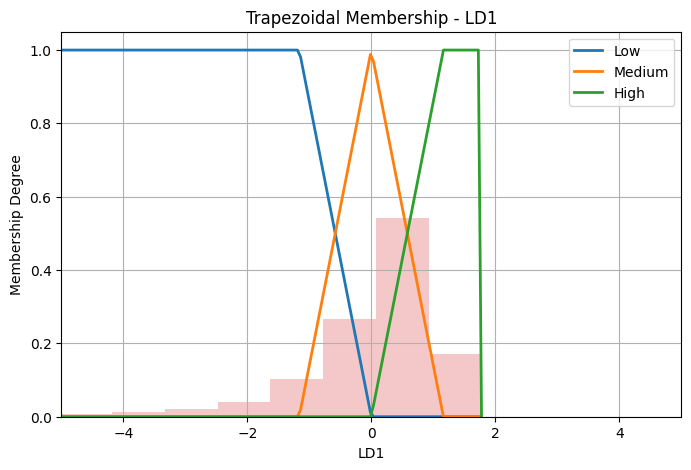

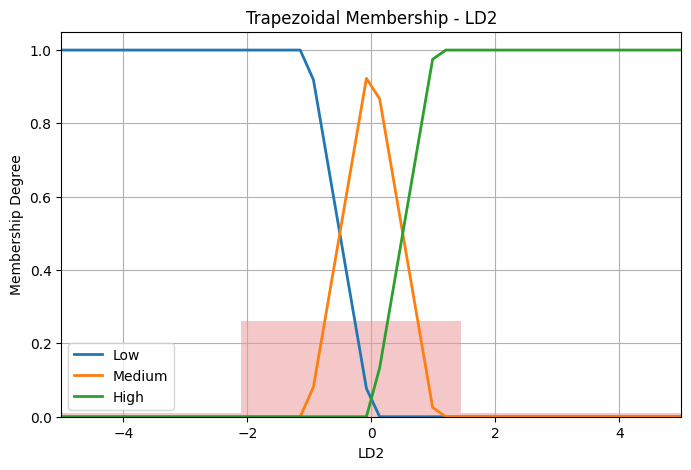

In [20]:
# Plot LD1
plot_mu_sigma_membership(fuzzy, X_lda, feature_index=0, feature_name="LD1")

# Plot LD2
plot_mu_sigma_membership(fuzzy, X_lda, feature_index=1, feature_name="LD2")

### Simulation

In [16]:
# Preparation Data
# Split 7-1-2
X_train, X_temp, y_train, y_temp = train_test_split(
    X_fuzzy, y_final, test_size=0.3, random_state=209, stratify=y_final
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.667, random_state=209, stratify=y_temp
)

print(f"Train set      : {X_train.shape[0]} samples ({X_train.shape[0]/len(X_fuzzy)*100:.1f}%)")
print(f"Validation set : {X_val.shape[0]} samples ({X_val.shape[0]/len(X_fuzzy)*100:.1f}%)")
print(f"Test set       : {X_test.shape[0]} samples ({X_test.shape[0]/len(X_fuzzy)*100:.1f}%)")
print(f"Total          : {len(X_fuzzy)} samples")
print(f"Input features : {X_fuzzy.shape[1]}")

# Save index for plot 
train_indices = y_train.index
val_indices = y_val.index
test_indices = y_test.index

print(f"\nIndices - Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

# Convert to tensor
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

# DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define FNN with Attention
class FNNWithAttention(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(FNNWithAttention, self).__init__()
        
        # Fully connected layers
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, 16)
        self.bn3 = nn.BatchNorm1d(16)
        
        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(16, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )
        
        # Output layer
        self.fc_out = nn.Linear(16, num_classes)
        
        # Regularization
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        # Hidden layers
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        
        # Attention weights
        attn_weights = self.attention(x)  # (batch_size, 1)
        attn_weights = F.softmax(attn_weights, dim=0)  # Normalize across batch
        
        # Apply attention (weighted features)
        x_attended = x * attn_weights
        
        # Output
        out = self.fc_out(x_attended)
        return out
# Initialization
model = FNNWithAttention(input_dim=X_fuzzy.shape[1], num_classes=3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-5)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2, eta_min=1e-5
        )

print("\n" + "=" * 60)
print("Model Architecture")
print("=" * 60)
print(model)

# Hitung jumlah parameter
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Training loop with validation
num_epochs = 50
train_losses = []
val_losses = []
test_losses = []  
train_accs = []
val_accs = []
train_f1_scores = []
val_f1_scores = []
learning_rates = []
train_aucs = []
val_aucs = []
test_aucs = []

test_accs_per_epoch = []
test_aucs_per_epoch = []
test_f1_scores_per_epoch = []
test_precision_per_epoch = []
test_recall_per_epoch = []

best_val_f1 = 0.0
best_epoch = 0
best_model_state = None
patience_counter = 0
early_stop_patience = 10

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_train_preds = []
    all_train_labels = []
    all_train_probs = []
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
      
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())
        probs = F.softmax(outputs, dim=1)
        all_train_probs.extend(probs.detach().cpu().numpy())   
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_f1 = f1_score(all_train_labels, all_train_preds, average='weighted')
    train_auc = roc_auc_score(all_train_labels, all_train_probs, multi_class='ovr', average='weighted')

    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1_scores.append(train_f1)
    train_aucs.append(train_auc)

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    all_val_preds = []
    all_val_labels = []
    all_val_probs = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())
            probs = F.softmax(outputs, dim=1)
            all_val_probs.extend(probs.detach().cpu().numpy())

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    val_f1 = f1_score(all_val_labels, all_val_preds, average='weighted')
    val_auc = roc_auc_score(all_val_labels, all_val_probs, multi_class='ovr', average='weighted')

    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1_scores.append(val_f1)
    val_aucs.append(val_auc)

    # Test phase (per epoch)
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    all_test_preds = []
    all_test_labels = []
    all_test_probs = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            all_test_preds.extend(predicted.cpu().numpy())
            all_test_labels.extend(labels.cpu().numpy())
            probs = F.softmax(outputs, dim=1)
            all_test_probs.extend(probs.detach().cpu().numpy())

    test_loss = test_loss / len(test_loader)
    test_acc = test_correct / test_total
    test_f1 = f1_score(all_test_labels, all_test_preds, average='weighted')
    test_precision = precision_score(all_test_labels, all_test_preds, average='weighted', zero_division=0)
    test_recall = recall_score(all_test_labels, all_test_preds, average='weighted', zero_division=0)
    test_auc = roc_auc_score(all_test_labels, all_test_probs, multi_class='ovr', average='weighted')

    test_losses.append(test_loss)
    test_accs_per_epoch.append(test_acc)
    test_f1_scores_per_epoch.append(test_f1)
    test_precision_per_epoch.append(test_precision)
    test_recall_per_epoch.append(test_recall)
    test_aucs_per_epoch.append(test_auc)

    # Record learning rate
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save best model based on F1-score
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= early_stop_patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break
    
    # Print progress
    if (epoch + 1) % 1 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
      f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}, Train AUC: {train_auc:.4f} | "
      f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}, Val AUC: {val_auc:.4f} | "
      f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}, Test AUC: {test_auc:.4f} | "
      f"LR: {current_lr:.2e}")

print(f"\nTraining complete! Best validation F1-score: {best_val_f1:.4f} ({best_val_f1*100:.2f}%) at epoch {best_epoch+1}")

# Load best model
model.load_state_dict(best_model_state)

# Plot metrics history
plt.figure(figsize=(18, 10))

# Plot loss
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss History (All Sets)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot accuracy
plt.subplot(2, 2, 2)
plt.plot(train_accs, label='Train Accuracy', linewidth=2)
plt.plot(val_accs, label='Validation Accuracy', linewidth=2)
plt.plot(test_accs_per_epoch, label='Test Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy History (All Sets)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot F1-score
plt.subplot(2, 2, 3)
plt.plot(train_f1_scores, label='Train F1-Score', linewidth=2)
plt.plot(val_f1_scores, label='Validation F1-Score', linewidth=2)
plt.plot(test_f1_scores_per_epoch, label='Test F1-Score', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.title('F1-Score History (All Sets)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(train_aucs, label='Train AUC', linewidth=2)
plt.plot(val_aucs, label='Validation AUC', linewidth=2)
plt.plot(test_aucs_per_epoch, label='Test AUC', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('AUC History (All Sets)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluation
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Classification report
print("\n" + "=" * 60)
print("Classification Report")
print("=" * 60)
print(classification_report(all_labels, all_preds, 
                          target_names=['Intermediate', 'Non-Spiral', 'Spiral'], digits=4))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                            display_labels=['Intermediate', 'Non-Spiral', 'Spiral'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='magma', values_format='d')
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

# Prediction Plot
X_test_lda = X_lda[test_indices]
y_test_array = y_test.values
y_pred_array = np.array(all_preds)

print(f"\nShape X_test_lda: {X_test_lda.shape}")
print(f"Shape y_test_array: {y_test_array.shape}")
print(f"Shape y_pred_array: {y_pred_array.shape}")

plt.figure(figsize=(15, 5))

# Plot 1: Ground Truth
plt.subplot(1, 3, 1)
colors = ['red', 'blue', 'green']
labels_map = ['Intermediate', 'Non-Spiral', 'Spiral']
for label in range(3):
    mask = y_test_array == label
    plt.scatter(
        X_test_lda[mask, 0],
        X_test_lda[mask, 1],
        #c=colors[label],
        label=labels_map[label],
        alpha=0.4,
        s=10
    )
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('Ground Truth Labels')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Predictions
plt.subplot(1, 3, 2)
for label in range(3):
    mask = y_pred_array == label
    plt.scatter(
        X_test_lda[mask, 0],
        X_test_lda[mask, 1],
        #c=colors[label],
        label=labels_map[label],
        alpha=0.4,
        s=10
    )
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('Predicted Labels')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Correct vs Misclassified
plt.subplot(1, 3, 3)
misclassified_mask = y_pred_array != y_test_array
plt.scatter(
    X_test_lda[~misclassified_mask, 0],
    X_test_lda[~misclassified_mask, 1],
    c='green', label='Correct', alpha=0.3, s=10
)
plt.scatter(
    X_test_lda[misclassified_mask, 0],
    X_test_lda[misclassified_mask, 1],
    c='red', label='Misclassified', alpha=0.6, s=20, edgecolors='black', linewidth=0.5
)
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('Correct vs Misclassified Predictions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 60)
print("Results")
print("=" * 60)
print(f"Train Loss         : {train_losses[-1]:.4f}")
print(f"Validation Loss    : {val_losses[-1]:.4f}")
print(f"Test Loss          : {test_losses[-1]:.4f}")
print(f"Train Accuracy     : {train_accs[-1]:.4f} ({train_accs[-1]*100:.2f}%)")
print(f"Train F1-Score     : {train_f1_scores[-1]:.4f} ({train_f1_scores[-1]*100:.2f}%)")
print(f"Validation Accuracy: {val_accs[-1]:.4f} ({val_accs[-1]*100:.2f}%)")
print(f"Validation F1-Score: {val_f1_scores[-1]:.4f} ({val_f1_scores[-1]*100:.2f}%)")
print(f"Best Validation F1 : {best_val_f1:.4f} ({best_val_f1*100:.2f}%) at epoch {best_epoch+1}")
print(f"Test Accuracy      : {accuracy_score(all_labels, all_preds):.4f} ({accuracy_score(all_labels, all_preds)*100:.2f}%)")
print(f"Test F1-Score      : {f1_score(all_labels, all_preds, average='weighted'):.4f} ({f1_score(all_labels, all_preds, average='weighted')*100:.2f}%)")
print(f"Test Precision     : {precision_score(all_labels, all_preds, average='weighted'):.4f} ({precision_score(all_labels, all_preds, average='weighted')*100:.2f}%)")
print(f"Test Recall        : {recall_score(all_labels, all_preds, average='weighted'):.4f} ({recall_score(all_labels, all_preds, average='weighted')*100:.2f}%)")

# Per-class metrics
print("\nPer-class Metrics:")
for i, label in enumerate(['Intermediate', 'Non-Spiral', 'Spiral']):
    precision = precision_score(all_labels, all_preds, labels=[i], average=None)[0]
    recall = recall_score(all_labels, all_preds, labels=[i], average=None)[0]
    f1 = f1_score(all_labels, all_preds, labels=[i], average=None)[0]
    print(f"  {label:12s}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

Train set      : 610541 samples (70.0%)
Validation set : 87133 samples (10.0%)
Test set       : 174528 samples (20.0%)
Total          : 872202 samples
Input features : 6

Indices - Train: 610541, Val: 87133, Test: 174528

Model Architecture
FNNWithAttention(
  (fc1): Linear(in_features=6, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (bn3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (attention): Sequential(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (fc_out): Linear(in_features=16, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Total parameters: 3,476

KeyboardInterrupt: 

In [17]:
best_test_accuracy = max(test_accs_per_epoch)
best_val_accuracy = max(val_accs)
print(f"Best Test Accuracy: {best_test_accuracy:.4f}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Test AUC          : {test_aucs_per_epoch[-1]:.4f}")
print(f"Validation AUC          : {val_aucs[-1]:.4f}")

Best Test Accuracy: 0.4884
Best Validation Accuracy: 0.4856
Test AUC          : 0.6754
Validation AUC          : 0.6718


In [ ]:
hasil_lda = pd.DataFrame(data=X_test_lda, columns=["LD1", "LD2"])
hasil_lda["Class"] = y_pred_array
# Save the results
hasil_lda.to_csv("hasil_lda_visual_over.csv", index=False)

In [19]:
hasil_lda

,LD1,LD2,Class
0,-0.259508,-0.151766,0
1,-0.815216,0.137942,2
2,-0.596141,-0.140081,0
3,-0.266803,-0.698526,0
4,2.769591,0.618704,1
...,...,...,...
174523,-0.616330,-3.269290,0
174524,-0.533158,-0.779315,0
174525,-0.809924,-0.302994,2
174526,0.177201,-3.088299,0


In [20]:
hasil_centroids = hasil_lda.groupby('Class')[['LD1', 'LD2']].mean()

# Display centroids
print(hasil_centroids)

            LD1       LD2
Class                    
0     -0.431654 -0.411405
1      0.911287 -0.011017
2     -0.822347  0.827679


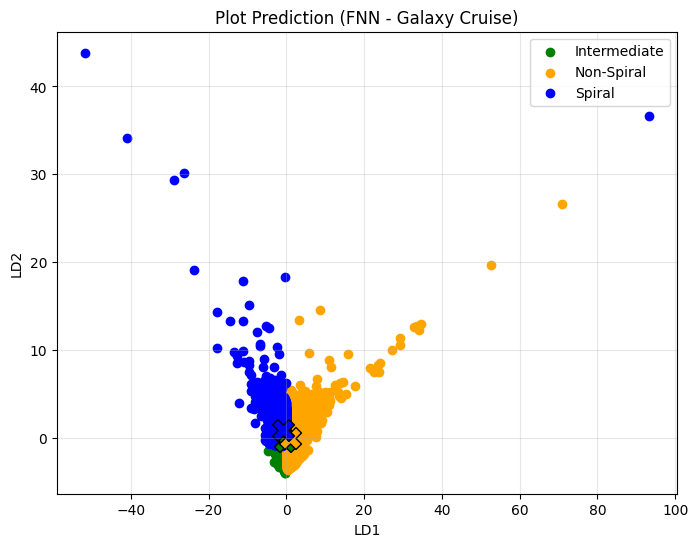

In [ ]:
# Plot prediction
class_names = ['Intermediate', 'Non-Spiral', 'Spiral']
colors = ['green', 'orange', 'blue']

plt.figure(figsize=(8,6))

# Plot data tiap kelas
for label in range(3):
    mask = y_pred_array == label
    plt.scatter(
        X_test_lda[mask, 0],
        X_test_lda[mask, 1],
        c=colors[label],
        label=labels_map[label]
    )

# Hitung centroid
centroids = hasil_lda.groupby('Class')[['LD1','LD2']].mean()

# Plot centroid + label
for i, class_id in enumerate(centroids.index):
    
    x = centroids.loc[class_id, 'LD1']
    y = centroids.loc[class_id, 'LD2']

    plt.scatter(
        x, y,
        color=colors[i],
        marker='X',
        s=250,
        edgecolors='black'
    )

plt.xlabel(f"LD1")
plt.ylabel(f"LD2")
plt.title("Plot Prediction (FNN - Galaxy Cruise)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<Figure size 800x600 with 0 Axes>

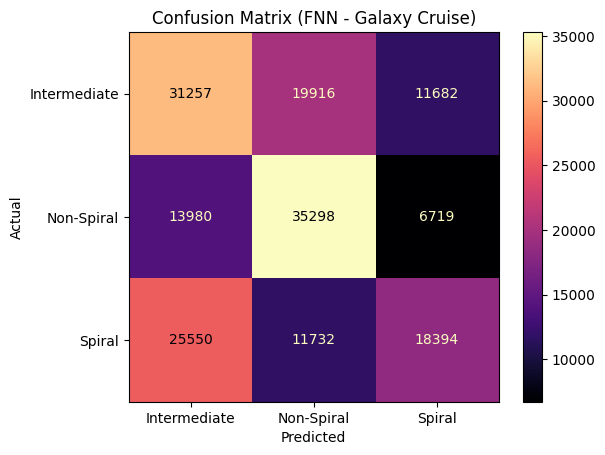

In [23]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=['Intermediate', 'Non-Spiral', 'Spiral'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='magma', values_format='d')
plt.title('Confusion Matrix (FNN - Galaxy Cruise)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.grid(False)
plt.show()